# 🎲 Sesión 7 — Simulación de la pérdida agregada S
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM

---

**Semana 3 · Cierre del Tema 1** · **Herramienta:** Python
**Proyecto:** el paso que convierte “ajusté dos distribuciones” en “tengo la pérdida de mi cartera”

---

> **Objetivo:** juntar la frecuencia y la severidad y **simular S**, obtener su distribución empírica,
> validarla contra E[S] y Var[S], y sacar cuantiles (VaR, TVaR). De aquí sale la prima del producto.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las de Ejercicio las completas tú.**

## Contenido
1. [Entorno](#1)
2. [Los dos ingredientes: N y X](#2)
3. [Simular el modelo colectivo S](#3)
4. [Distribución empírica de S y validación](#4)
5. [Cuantiles: VaR y TVaR de S](#5)
6. [¿Cuántas simulaciones bastan?](#6)
7. [Cierre → prima y Práctica A2](#7)

---

---
<a id='1'></a>
## 1. Entorno

In [11]:
# ─── Entorno ────────────────────────────────────────────────────────────────
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(7)
plt.rcParams["figure.figsize"] = (8, 3.8)
print("✓ listo")

✓ listo


---
<a id='2'></a>
## 2. Los dos ingredientes: N y X

Ya sabemos ajustar cada pieza. Aquí las tenemos como objetos de `scipy` y las simulamos **por separado**:
la **frecuencia** N (cuántos siniestros) y la **severidad** X (cuánto cuesta cada uno).

In [12]:
# ─── Frecuencia y severidad de la cartera ──────────────────────────────────
sev  = stats.lognorm(s=0.9, scale=180)     # severidad (Sesiones 2–3)
freq = stats.poisson(10)                    # frecuencia (Sesiones 4–5): media 10 siniestros

print("5 simulaciones de N (conteo):   ", freq.rvs(5))
print("5 simulaciones de X (montos):   ", sev.rvs(5).round(0))
print(f"\nE[N] = {freq.mean():.1f}   E[X] = {sev.mean():,.1f}")

5 simulaciones de N (conteo):    [ 9 10  8  9  8]
5 simulaciones de X (montos):    [145.  49. 297. 201. 230.]

E[N] = 10.0   E[X] = 269.9


---
<a id='3'></a>
## 3. Simular el modelo colectivo S

El algoritmo: para cada simulación, saco un N, sumo N severidades, y eso es **una** realización de S.
Repito muchas veces. Fíjate que N es aleatorio, así que cada simulación suma un número distinto de montos.

In [13]:
# ─── Simulador del modelo colectivo ────────────────────────────────────────
def simular_S(frecuencia, M=50_000, seed=None):
    if seed is not None:
        np.random.seed(seed)
    N = frecuencia.rvs(M)                    # un conteo por simulación
    X = sev.rvs(int(N.sum()))                # todas las severidades de golpe
    idx = np.repeat(np.arange(M), N)         # a qué simulación pertenece cada monto
    return np.bincount(idx, weights=X, minlength=M)   # suma por simulación

S = simular_S(freq, seed=1)
print(f"{len(S):,} realizaciones de S")
print("primeras 8:", S[:8].round(0))
print(f"proporción con S = 0 (ningún siniestro): {(S == 0).mean():.2%}")

50,000 realizaciones de S
primeras 8: [1910. 1604. 1341. 1566. 1269. 4716. 1491. 3697.]
proporción con S = 0 (ningún siniestro): 0.01%


### ✏️ Ejercicio 1 — cambia la escala de la cartera

1. Simula S con una frecuencia menor, `stats.poisson(5)`, y `M = 20000`.
2. Reporta la media de esa S y compárala con E[N]·E[X] = 5 · E[X].

In [14]:
# Tu código aquí 👇
# Pista: simular_S(stats.poisson(5), M=20000, seed=3)


---
<a id='4'></a>
## 4. Distribución empírica de S y validación

Las 50 000 realizaciones **son** la distribución de S. La graficamos, y la **validamos** contra las
fórmulas analíticas de la Sesión 5.

                      simulado       teórico
media E[S]               2,697         2,699
varianza Var[S]      1,620,289     1,637,201

Si cuadran, la simulación es confiable.


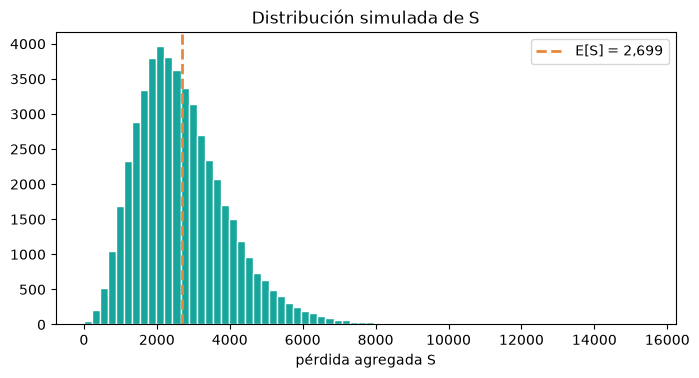

In [15]:
# ─── Histograma + validación contra E[S] y Var[S] ──────────────────────────
EN, VarN = 10, 10                    # Poisson: Var[N] = E[N]
EX, VarX = sev.mean(), sev.var()
ES_teo   = EN * EX
VarS_teo = EN * VarX + VarN * EX**2

print(f"{'':16}{'simulado':>14}{'teórico':>14}")
print(f"{'media E[S]':16}{S.mean():>14,.0f}{ES_teo:>14,.0f}")
print(f"{'varianza Var[S]':16}{S.var():>14,.0f}{VarS_teo:>14,.0f}")
print("\nSi cuadran, la simulación es confiable.")

plt.hist(S, bins=70, color="#17A69B", edgecolor="white")
plt.axvline(ES_teo, color="#E8873C", ls="--", lw=2, label=f"E[S] = {ES_teo:,.0f}")
plt.title("Distribución simulada de S"); plt.xlabel("pérdida agregada S"); plt.legend(); plt.show()

### ✏️ Ejercicio 2 — mide el error de la validación

1. Calcula el error relativo entre la media simulada de `S` y `ES_teo`.
2. Haz lo mismo para la varianza. ¿Están por debajo del 1–2%?

In [16]:
# Tu código aquí 👇
# Pista: abs(S.mean() - ES_teo) / ES_teo


---
<a id='5'></a>
## 5. Cuantiles: VaR y TVaR de S

Con las S simuladas, el **VaR** es un percentil y el **TVaR** es el promedio más allá de ese percentil.
Comparamos frecuencia Poisson vs. binomial negativa: misma media, distinta cola.

In [17]:
# ─── VaR y TVaR al 99% ─────────────────────────────────────────────────────
freq_nb = stats.nbinom(10, 0.5)          # media 10, varianza 20 (sobredispersa)
S_nb = simular_S(freq_nb, seed=2)

def var_tvar(arr, p=0.99):
    var = np.percentile(arr, p * 100)
    tvar = arr[arr > var].mean()
    return var, tvar

print(f"{'Frecuencia':16}{'E[S]':>10}{'VaR99':>10}{'TVaR99':>10}")
for nombre, arr in [("Poisson", S), ("Bin. negativa", S_nb)]:
    v, t = var_tvar(arr)
    print(f"{nombre:16}{arr.mean():>10,.0f}{v:>10,.0f}{t:>10,.0f}")
print("\nMisma media E[S], pero la binomial negativa engorda la cola → VaR y TVaR más altos.")

Frecuencia            E[S]     VaR99    TVaR99
Poisson              2,697     6,527     7,540
Bin. negativa        2,688     7,308     8,381

Misma media E[S], pero la binomial negativa engorda la cola → VaR y TVaR más altos.


### ✏️ Ejercicio 3 — otro nivel de confianza

1. Calcula el VaR y el TVaR de `S` al **95%** (usa la función `var_tvar`).
2. ¿Cuánto más grande es el TVaR99 que el VaR99? (usa los de la celda anterior).

In [18]:
# Tu código aquí 👇
# Pista: var_tvar(S, p=0.95)


---
<a id='6'></a>
## 6. ¿Cuántas simulaciones bastan?

La simulación es aproximada. Vemos cómo la estimación de E[S] se **estabiliza** al aumentar el número
de simulaciones (media corrida).

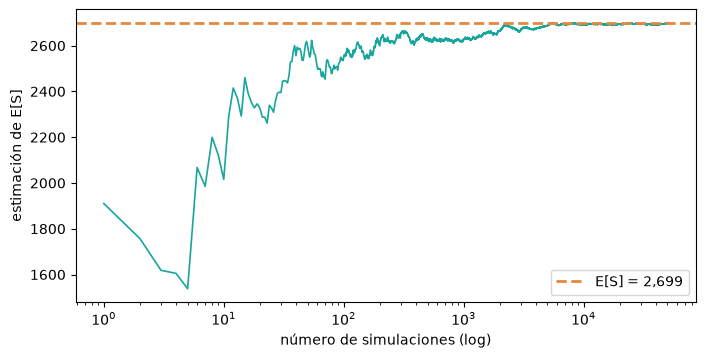

Estimación con    100 simulaciones: 2,548
Estimación con 50,000 simulaciones: 2,697   (teórica 2,699)


In [19]:
# ─── Convergencia de la estimación ─────────────────────────────────────────
run = np.cumsum(S) / np.arange(1, len(S) + 1)

plt.plot(np.arange(1, len(S) + 1), run, color="#17A69B", lw=1.2)
plt.axhline(ES_teo, color="#E8873C", ls="--", lw=2, label=f"E[S] = {ES_teo:,.0f}")
plt.xscale("log"); plt.xlabel("número de simulaciones (log)"); plt.ylabel("estimación de E[S]")
plt.legend(); plt.show()

print(f"Estimación con    100 simulaciones: {run[99]:,.0f}")
print(f"Estimación con 50,000 simulaciones: {run[-1]:,.0f}   (teórica {ES_teo:,.0f})")

### ✏️ Ejercicio 4 — la cola necesita más

1. Estima el VaR99 de `S` usando solo las primeras **1,000** simulaciones y luego con las **50,000**.
2. ¿Cuál se acerca más al valor “estable”? ¿Por qué la cola necesita más simulaciones que la media?

In [20]:
# Tu código aquí 👇
# Pista: np.percentile(S[:1000], 99)  vs  np.percentile(S, 99)


---
<a id='7'></a>
## 7. Cierre → prima y Práctica A2

Con S simulada tienes lo que la nota técnica necesita:

- **Prima pura** = E[S] (la media de tus S simuladas).
- **Recargo de seguridad**: un margen sobre E[S] ligado a la cola (VaR/TVaR).
- **Coberturas**: el costo de un deducible o un límite a nivel cartera es una esperanza sobre S,
  por ejemplo `np.maximum(S - d, 0).mean()`.

> Esto es exactamente la **Práctica A2 (modelo colectivo)**: simular S de tu ramo y sacar de ahí la prima.
> El Stop-Loss sobre S es un caso más — lo verás en el Tema 5, con el adjunto.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Semana 3 · Sesión 7*